# Baseline model — smoke tests
Exercises every function in `baseline_model.py` end-to-end.

In [1]:
from baseline_model import *
from figures import *

## 1. Structural quantities

In [14]:
par = Params(d=0.15, p=0.01, s=0.3, a=0.05, gamma=2.0, w=1.0)

print(f"c_I  = {c_I(par):.6f}")
print(f"c_UN = {c_UN(par):.6f}")
print(f"c_UF = {c_UF(par):.6f}")
print(f"q*   = {q_star(par):.6f}")
print(f"Δu   = {delta_u(par):.8f}")
print(f"π    = {premium(par):.6f}")
print(f"V_I  = {value_insured(par):.6f}")
print(f"V_U  = {value_uninsured(par):.6f}")
print(f"internality = {internality(par):.8f}")

c_I  = 0.998950
c_UN = 1.000000
c_UF = 0.857500
q*   = 0.006325
Δu   = 0.16618076
π    = 0.001050
V_I  = -1.001051
V_U  = -1.001662
internality = 0.00061070


## 2. Calibration: recover f(q*) and fit Beta distribution

In [15]:
I_obs   = 0.50
epsilon = -1.   # price elasticity of take-up (negative)

f_hat = recover_fqstar(I_obs, epsilon, par)
print(f"f(q*) from elasticity: {f_hat:.6f}")

alpha, beta_ = fit_beta(I_obs, epsilon, par)
print(f"Beta fit: alpha = {alpha:.4f},  beta = {beta_:.4f}")

par_cal = replace(par, alpha=alpha, beta_=beta_)
I_check   = take_up(par_cal)
fqs_check = density_at_margin(par_cal)
print(f"\nVerification:")
print(f"  take_up    = {I_check:.6f}  (target {I_obs})")
print(f"  f(q*) check = {fqs_check:.6f}  (target {f_hat:.6f})")

f(q*) from elasticity: 78.967601
Beta fit: alpha = 1.8185,  beta = 235.7030

Verification:
  take_up    = 0.500000  (target 0.5)
  f(q*) check = 78.967601  (target 78.967601)


In [16]:
# Convenience entry point
par_cal2 = calibrate(d=0.15, p=0.01, I_obs=0.50, epsilon=-1., s=0.1, a=0.05)
print(f"calibrate() → alpha={par_cal2.alpha:.4f},  beta_={par_cal2.beta_:.4f}")

calibrate() → alpha=1.8147,  beta_=182.5510


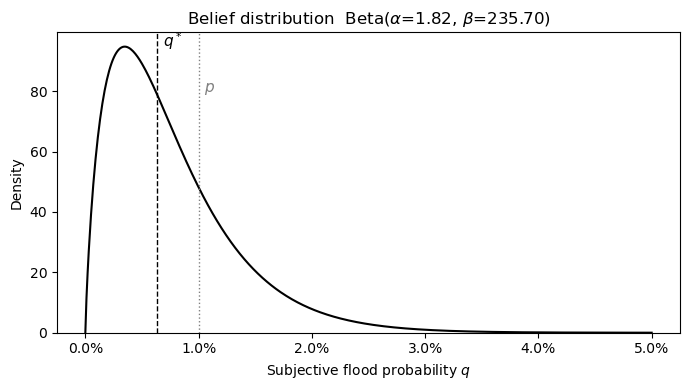

In [17]:
plot_beta(par_cal);

## 3. Analytical MVPF formulas

Each MVPF = (direct benefit + internality) / (direct cost + fiscal externality).
The bars show numerator and denominator components separately; the MVPF is the ratio.

∂I/∂s  = 0.714286
∂I/∂a  = -0.613135
                                   Subsidy s      Relief a
----------------------------------------------------------
  Direct benefit                   +0.000752     +0.001020
  Internality correction           +0.000436     -0.000374
  Numerator (total)                +0.001188     +0.000646

  Direct cost                      +0.000750     +0.000750
  Fiscal externality               +0.000268     -0.000230
  Denominator (total)              +0.001018     +0.000520
----------------------------------------------------------
  MVPF                               +1.1670       +1.2412


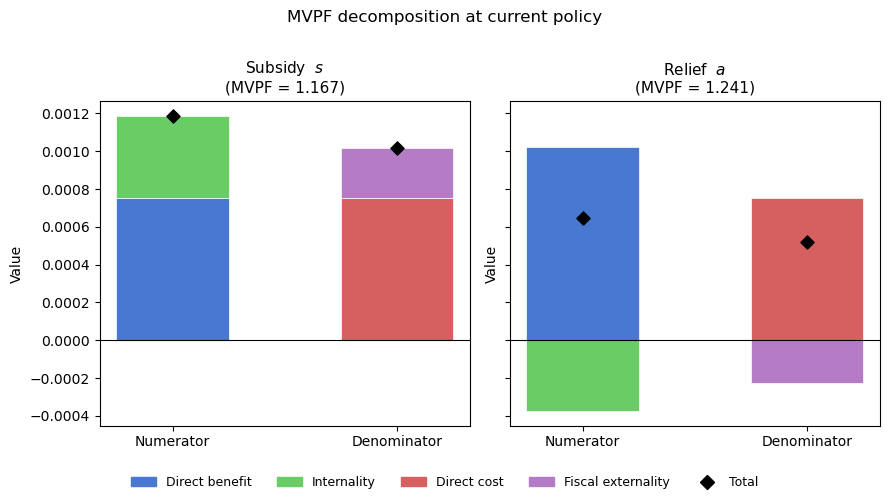

In [18]:
dIds = dI_ds(par_cal, fqs=fqs_check)
dIda = dI_da(par_cal, fqs=fqs_check)
print(f"∂I/∂s  = {dIds:.6f}")
print(f"∂I/∂a  = {dIda:.6f}")

print_mvpf_table(par_cal, I_check, fqs_check)
plot_mvpf_decomp(par_cal, I_check, fqs_check);

## 4. Policy optimisation

In [19]:
B = fiscal_cost(par_cal, I_check)
print(f"Budget at current policy: B = {B:.6f}")

# Numerical optimisation
s_num, a_num = optimize_policy_numerical(par_cal, B)
par_num = replace(par_cal, s=s_num, a=a_num)
I_num   = take_up(par_num)
fqs_num = density_at_margin(par_num)
print(f"\nNumerical:  s* = {s_num:.4f},  a* = {a_num:.4f}")
print(f"  MVPF_s = {mvpf_subsidy(par_num, I_num, fqs_num):.4f},  "
      f"MVPF_a = {mvpf_relief(par_num, I_num, fqs_num):.4f}")
print(f"  welfare = {welfare(par_num, I_num):.8f}")

# MVPF-condition optimisation
s_mvpf, a_mvpf = optimize_policy_mvpf(par_cal, B)
par_mvpf = replace(par_cal, s=s_mvpf, a=a_mvpf)
I_mvpf   = take_up(par_mvpf)
fqs_mvpf = density_at_margin(par_mvpf)
print(f"\nMVPF-based: s* = {s_mvpf:.4f},  a* = {a_mvpf:.4f}")
print(f"  MVPF_s = {mvpf_subsidy(par_mvpf, I_mvpf, fqs_mvpf):.4f},  "
      f"MVPF_a = {mvpf_relief(par_mvpf, I_mvpf, fqs_mvpf):.4f}")
print(f"  welfare = {welfare(par_mvpf, I_mvpf):.8f}")

Budget at current policy: B = 0.000262

Numerical:  s* = 0.2229,  a* = 0.1452
  MVPF_s = 1.1924,  MVPF_a = 1.1924
  welfare = -1.00135418

MVPF-based: s* = 0.2228,  a* = 0.1452
  MVPF_s = 1.1924,  MVPF_a = 1.1924
  welfare = -1.00135418


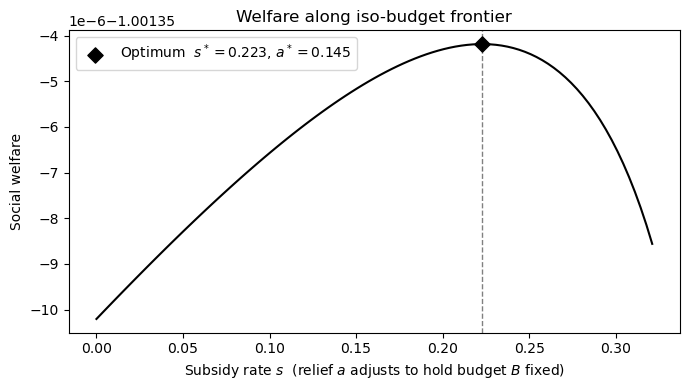

In [20]:
plot_welfare_frontier(par_cal, B);

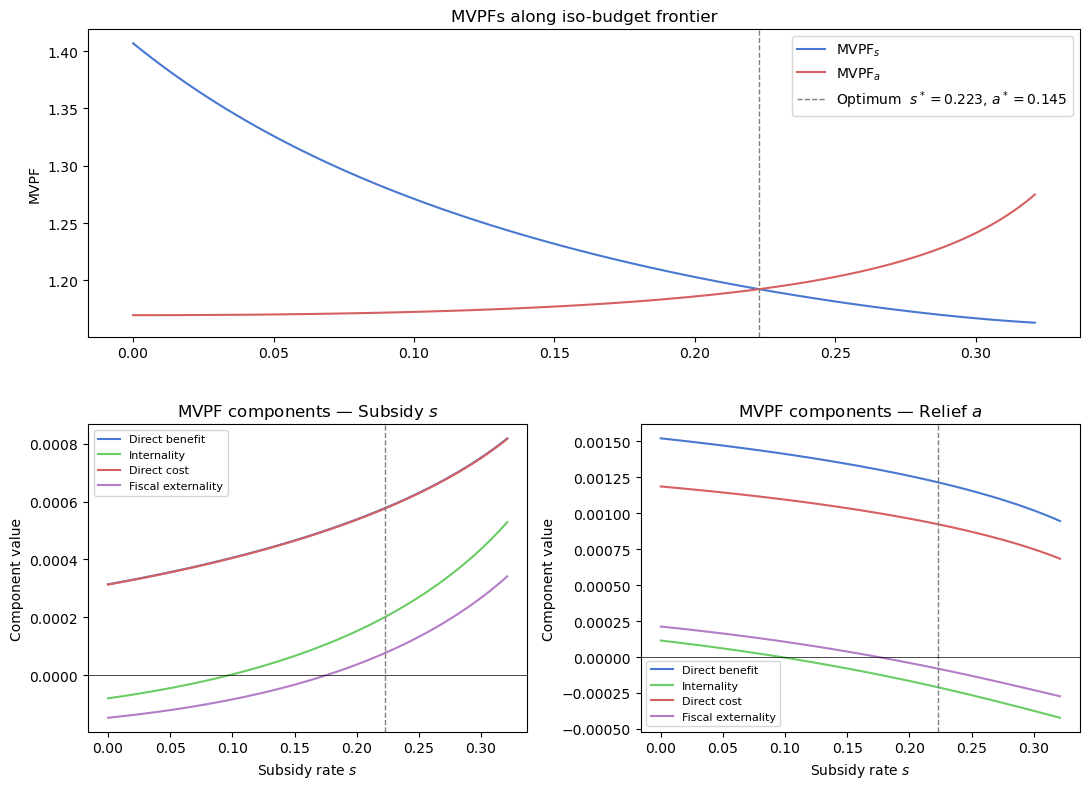

In [21]:
plot_mvpf_frontier(par_cal, B);